# 02 Collect Sources

USGS active streamgages, reviewed streamgage network artifacts, STREAM-geo/NLDI river geometry, direct AORC SST rainfall members, and NWM soil-moisture context.

In [1]:
import sys
from pathlib import Path

import pandas as pd
from IPython.display import display

location_root = Path("..").resolve()
repo_root = location_root.parents[1]
src_root = repo_root / "src"
sys.path.insert(0, str(src_root))

# plan reruns, reuse reviewed data, and audit readiness.
import design_events.collect_sources.workflow as collect

runtime = collect.load_runtime(location_root)
config = runtime.runtime_config
paths = runtime.runtime_paths
reviewed_network_path = runtime.reviewed_network_path

display(collect.summary(config, paths))
display(collect.source_records(runtime))

location                                                   greensboro
sources_root        /home/grahamhults/projects/Flood-RM/locations/...
collection_start                                           1979-02-01
collection_end                                             2022-12-31
Name: source_collection, dtype: str

,record,configured,location_root_syntax,exists
0,active USGS streamgage candidates,data/sources/usgs_streamgages/streamgage_candi...,"location_root / ""data/sources/usgs_streamgages...",True
1,reviewed streamgage network,data/sources/usgs_streamgages/streamgage_netwo...,"location_root / ""data/sources/usgs_streamgages...",True
2,reviewed discharge records,data/sources/usgs_streamgages/streamflow_recor...,"location_root / ""data/sources/usgs_streamgages...",True
3,AORC rainfall members,data/sources/aorc_sst/rainfall_members.csv,"location_root / ""data/sources/aorc_sst/rainfal...",True
4,NWM soil-moisture members,data/sources/nwm/soil_moisture.csv,"location_root / ""data/sources/nwm/soil_moistur...",True
5,STREAM-geo river geometry cache,data/sources/national_hydrography/stream_geo.p...,"location_root / ""data/sources/national_hydrogr...",True
6,NLDI STREAM-geo COMID join cache,data/sources/national_hydrography/nldi_stream_...,"location_root / ""data/sources/national_hydrogr...",False
7,NHDPlusV2 flowlines for STREAM-geo join,data/sources/national_hydrography/nhdplus_v2_f...,"location_root / ""data/sources/national_hydrogr...",False
8,NHDPlus river geometry,data/sources/national_hydrography/nhdplus_hr_r...,"location_root / ""data/sources/national_hydrogr...",True
9,NHDPlus catchments,data/sources/national_hydrography/nhdplus_hr_c...,"location_root / ""data/sources/national_hydrogr...",True


## Rerun Control

In [2]:
rerun = True

## Source Collection Plan

In [3]:
plan = collect.plan(config, paths)
plan_table = collect.plan_table(
    plan,
    paths,
    rerun=rerun,
)
display(plan_table)

,source,start,end,will_reuse_existing,action
0,usgs_streamgages,1979-02-01,2022-12-31,False,collect or repair
1,stream_geo_nldi,1979-02-01,2022-12-31,False,collect or repair
2,national_hydrography,1979-02-01,2022-12-31,False,collect or repair
3,nwm,1979-02-01,2022-12-31,False,collect or repair
4,aorc_sst,1979-02-01,2022-12-31,False,collect or repair


## USGS Active Streamgage Discovery

In [4]:
discovery_summary, records_summary = collect.discover_gages(runtime)
display(discovery_summary)
display(records_summary)
display(collect.gage_readiness(runtime))


provider                                                           USGS NWIS
site_service_url                   https://waterservices.usgs.gov/nwis/site/
parameter_cd                                                           00060
site_status                                                           active
data_types                                                                dv
bbox                                -80.628878,35.135683,-77.99173,37.218212
search_geometry             data/static/aoi/wflow_nhdplus_watersheds.geojson
hydrologic_buffer_km                                                      50
active_records_only                                                     True
candidate_output           data/sources/usgs_streamgages/streamgage_candi...
candidate_output_exists                                                 True
Name: usgs_active_streamgage_discovery, dtype: object

records_service                                                           dv
records_output             data/sources/usgs_streamgages/streamflow_recor...
records_output_exists                                                   True
request_timeout_seconds                                                   60
stat_cd                                                                00003
Name: usgs_reviewed_discharge_records, dtype: object

,artifact,path,exists,ready
0,streamgage candidates,/home/grahamhults/projects/Flood-RM/locations/...,True,True
9,soil moisture,/home/grahamhults/projects/Flood-RM/locations/...,True,True


## Stochastic Storm Transposition Region

The SST region is defined in `config.yaml`

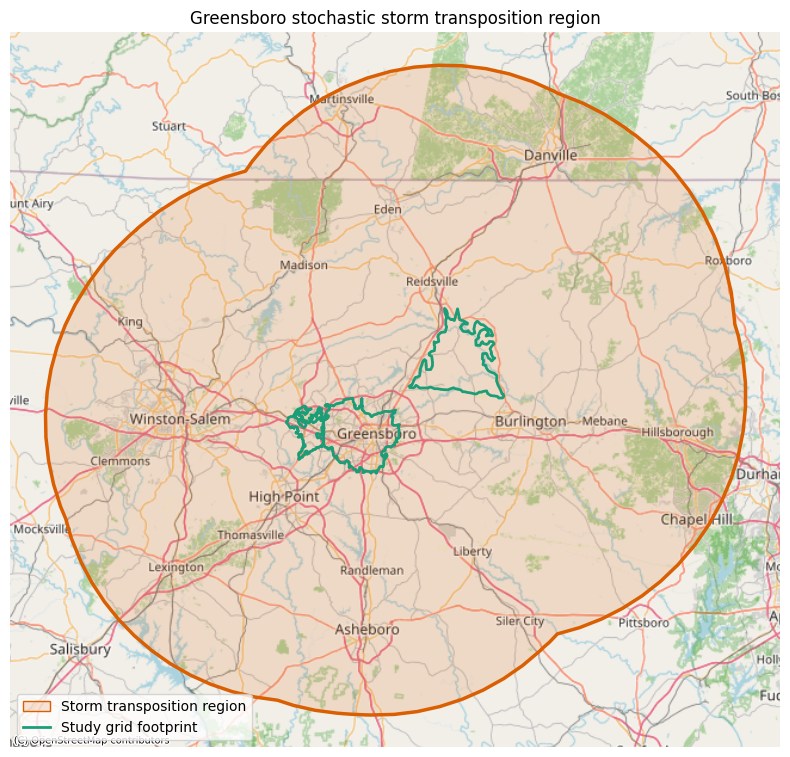

In [5]:
# Plot the configured AORC SST transposition region before pulling rainfall members.
fig, ax = collect.plot_sst_region(config, paths)

## STREAM-geo/NLDI River Geometry

STREAM-geo width/depth estimates are cached for native Wflow river-geometry enrichment; NLDI is retained as the COMID lookup provenance path.


In [6]:
display(collect.stream_sources(config, paths))


source                                                           STREAM-geo/NLDI
stream_geo_table               data/sources/national_hydrography/stream_geo.p...
stream_geo_table_exists                                                     True
nldi_lookup_cache              data/sources/national_hydrography/nldi_stream_...
nldi_lookup_cache_exists                                                   False
nhdplus_v2_flowlines           data/sources/national_hydrography/nhdplus_v2_f...
nhdplus_v2_flowlines_exists                                                False
stream_geo_join_method                                        attribute_transfer
nldi_role                                                COMID lookup provenance
manifest                       /home/grahamhults/projects/Flood-RM/locations/...
manifest_exists                                                             True
Name: stream_geo_nldi, dtype: object

## Direct AORC SST Rainfall Members

The direct AORC SST collector scans the transposition region, ranks rolling storm windows, and writes the rainfall-member table for precipitation pairing with streamflow and antecedent soil-moisture states.


In [7]:
# --- AORC SST collection parameters (edit to retune, then run Run Collection below) ---
# Threshold-driven POT: keep every INDEPENDENT storm whose 72h footprint-mean depth
# exceeds the threshold, so the rainfall-member count is data-driven
# Set the threshold from the rainfall POT diagnostics; raise it for fewer, heavier members.
min_precip_threshold = 50.0   # mm over the 72h storm window (footprint mean)
decluster_hours = 72          # minimum spacing between independent storms
storm_duration_hours = 72     # SST rainfall accumulation window
check_every_n_hours = 6       # transposition scan stride
defer_event_windows = True    # write AORC event-window NetCDFs in the separate cell below

display(collect.aorc_sst_params(
    config,
    paths,
    min_precip_threshold=min_precip_threshold,
    decluster_hours=decluster_hours,
    storm_duration_hours=storm_duration_hours,
    check_every_n_hours=check_every_n_hours,
    defer_event_windows=defer_event_windows,
))

source                                                       direct_aorc_sst
transposition_region_id                    greensboro-inland-review-required
transposition_region       data/sources/aorc_sst/transposition_regions/tr...
start_date                                                        1979-02-01
end_date                                                          2022-12-31
selection                  threshold-driven POT (every independent storm ...
min_precip_threshold_mm                                                 50.0
storm_duration_hours                                                      72
decluster_hours                                                           72
check_every_n_hours                                                        6
top_n_events_safety_cap                                                 None
defer_event_windows                                                     True
rainfall_members           /home/grahamhults/projects/Flood-RM/locations/...

## NWM Soil-Moisture Context

Selected NWM LDAS soil-moisture cells are retained for antecedent-condition pairing. Inland streamflow frequency uses reviewed USGS gages, so NWM streamflow remains context rather than the production frequency source.


In [8]:
display(collect.soil_sources(config, paths))

version                                                                                3.0
streamflow_available                                                                 False
streamflow_reason                                                                     None
soil_moisture_points                                                                     0
soil_moisture_variables                                              [SOIL_M, SOILSAT_TOP]
soil_moisture_zarr                       s3://noaa-nwm-retrospective-3-0-pds/CONUS/zarr...
soil_moisture_csv                        /home/grahamhults/projects/Flood-RM/locations/...
soil_moisture_exists                                                                  True
soil_moisture_has_requested_variables                                                 True
Name: nwm_soil_moisture, dtype: object

## Run Collection

In [ ]:
# Collect any missing configured sources and summarize the artifacts.
prerequisite_result = collect.prepare(config, paths)
collection_result = collect.run_collect(
 config,
 paths,
 plan,
 run_collection=True,
 skip_existing=not rerun,
 stop_on_error=False,
)
display(pd.concat([
 prerequisite_result.assign(table="collection_prerequisite"),
 collection_result.assign(table="collection_result"),
], ignore_index=True, sort=False))

## AORC SST Event Windows

In [ ]:
# Materialize missing per-storm AORC event-window NetCDFs after the ranked catalog exists.
aorc_event_window_result = collect.collect_aorc_sst_event_windows(
    config,
    paths,
    plan,
    skip_existing=True,
)
display(aorc_event_window_result)

## Reviewed Streamgage Network Writer

In [ ]:
reviewed_network_write = collect.write_gage_network(runtime)
reviewed_streamgage_decision_table = reviewed_network_write.decision_table
reviewed_network_result = reviewed_network_write.result

display(reviewed_streamgage_decision_table)
display(pd.Series(reviewed_network_result, name="reviewed_streamgage_network"))

# USGS Reviewed Discharge Records
reviewed_records_result = collect.collect_gage_records(runtime, skip_existing=not rerun)
display(pd.Series(reviewed_records_result, name="usgs_reviewed_discharge_records"))


,site_no,review_status,roles,frequency_basis,wflow_submodel_id,sfincs_domain_id,sfincs_handoff_id,review_notes
0,02075045,accepted_with_warning,"[frequency, calibration, validation]",greensboro_rural,greensboro_rural,greensboro_rural,None,HUC-derived active discharge gage inside 03030...
1,02075500,accepted_with_warning,"[frequency, calibration, validation]",greensboro_rural,greensboro_rural,greensboro_rural,None,HUC-derived active discharge gage inside 03030...
2,02076000,accepted_with_warning,"[frequency, calibration, validation]",greensboro_rural,greensboro_rural,greensboro_rural,None,HUC-derived active discharge gage inside 03030...
3,02077200,accepted_with_warning,"[frequency, calibration, validation]",greensboro_rural,greensboro_rural,greensboro_rural,None,HUC-derived active discharge gage inside 03030...
4,02077303,accepted_with_warning,"[frequency, calibration, validation]",greensboro_rural,greensboro_rural,greensboro_rural,None,HUC-derived active discharge gage inside 03030...
5,02077670,accepted_with_warning,"[frequency, calibration, validation]",greensboro_rural,greensboro_rural,greensboro_rural,None,HUC-derived active discharge gage inside 03030...
6,02093800,accepted_with_warning,"[frequency, calibration, validation]",greensboro_rural,greensboro_rural,greensboro_rural,None,HUC-derived active discharge gage inside 03030...
7,02093877,accepted_with_warning,"[frequency, calibration, validation]",greensboro_rural,greensboro_rural,greensboro_rural,None,HUC-derived active discharge gage inside 03030...
8,0209399200,accepted_with_warning,"[frequency, calibration, validation]",greensboro_rural,greensboro_rural,greensboro_rural,None,HUC-derived active discharge gage inside 03030...
9,02094500,accepted_with_warning,"[frequency, calibration, validation]",greensboro_rural,greensboro_rural,greensboro_rural,None,HUC-derived active discharge gage inside 03030...


reviewed_network_geojson /home/grahamhults/projects/Flood-RM/locations/...
reviewed_count 33
accepted_count 33
Name: reviewed_streamgage_network, dtype: object

## Collected Data Overview

In [ ]:
display(collect.overview())

### SST

Storm transposition targets are plotted against the configured SST region and study area.


In [ ]:
# Plot the SST region, study area, and rainfall transposition targets.
fig, ax = collect.plot_collected_sst_geography(config, paths)

### USGS Streamgages

Reviewed streamgages are plotted against the same source geography used during the review gate: evaluation footprint, SFINCS coverage, Wflow watershed search domain, and SST region.


In [ ]:
# Plot reviewed and candidate USGS streamgages over the source review geography.
fig, artifact_summary, gage_domain_summary = collect.plot_usgs_streamgage_network(runtime)
display(artifact_summary)
display(gage_domain_summary)

### NWM Soil Moisture

Soil moisture is summarized across configured NWM points and layers.


In [ ]:
# Plot monthly mean NWM soil moisture variables when available.
fig, status = collect.plot_nwm_soil_moisture(config, paths)
display(status)

### AORC SST Rainfall

Rainfall members are shown as selected-event magnitude and distribution summaries.


In [ ]:
# Plot compact AORC SST rainfall member summaries.
fig = collect.plot_aorc_sst_rainfall(paths)